In [1]:
import os
import glob
import json

# 改成你实际保存文章的文件夹
folder = "knowledge_base_sample"

def load_markdown_files(folder):
    """读取文件夹下所有 md 文件"""
    docs = []

    files = glob.glob(os.path.join(folder, "*.md"))

    for file_path in files:
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        docs.append({
            "file": file_path,
            "text": text
        })

    return docs

docs = load_markdown_files(folder)

print(f"共读取 {len(docs)} 篇文档")

for doc in docs[:3]:
    print(doc["file"])

共读取 10 篇文档
knowledge_base_sample/knowledge_base_article_10_防治马驴骡“肠臌气病”.md
knowledge_base_sample/knowledge_base_article_1_泥鳅的主要食物都有啥.md
knowledge_base_sample/knowledge_base_article_2_鸭患软腿病咋办.md


In [2]:
import os
import glob
import json

# 你的文章文件夹
folder = "knowledge_base_sample"

# 1. 读取 Markdown 文件
def load_markdown_files(folder):
    docs = []
    files = glob.glob(os.path.join(folder, "*.md"))

    for file_path in files:
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        docs.append({
            "file": file_path,
            "text": text
        })

    return docs


# 2. 按 Markdown 二级标题分块
def chunk_by_headings(text):
    """按 Markdown 二级标题分块；如果没有 ## 标题，则按段落分块"""
    if "## " in text:
        sections = text.split("## ")
        chunks = []

        for section in sections:
            section = section.strip()
            if section:
                chunks.append("## " + section)

        return chunks
    else:
        # 如果没有二级标题，就按段落分块
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        return paragraphs


# 3. 生成 all_chunks
docs = load_markdown_files(folder)

print(f"共读取 {len(docs)} 篇文档")

all_chunks = []

for doc in docs:
    chunks = chunk_by_headings(doc["text"])

    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "source_file": doc["file"],
            "chunk_id": i + 1,
            "content": chunk
        })

print(f"共生成 {len(all_chunks)} 个文本块")

# 4. 保存分块结果
os.makedirs("chunks", exist_ok=True)

with open("chunks/heading_chunks.json", "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)

print("分块结果已保存到 chunks/heading_chunks.json")

共读取 10 篇文档
共生成 83 个文本块
分块结果已保存到 chunks/heading_chunks.json


In [3]:
import os
import glob

def chunk_by_headings(text):
    """按 Markdown 二级标题分块"""
    sections = text.split("## ")
    chunks = []
    for section in sections:
        section = section.strip()
        if section:
            chunks.append("## " + section)
    return chunks


def build_chunks(folder="knowledge_base_sample"):
    """读取文件夹中的 Markdown 文档，并返回 chunks"""
    files = glob.glob(os.path.join(folder, "*.md"))
    all_chunks = []

    for file_path in files:
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        chunks = chunk_by_headings(text)

        for i, chunk in enumerate(chunks, 1):
            all_chunks.append({
                "source_file": file_path,
                "chunk_id": i,
                "content": chunk
            })

    return all_chunks


all_chunks = build_chunks("knowledge_base_sample")

print(f"共生成 {len(all_chunks)} 个 chunks")
all_chunks[:3]

共生成 10 个 chunks


[{'source_file': 'knowledge_base_sample/knowledge_base_article_10_防治马驴骡“肠臌气病”.md',
  'chunk_id': 1,
  'content': '## # 防治马驴骡“肠臌气病”\n\n来源链接：https://cast.caas.cn/kj/syjs/dwyx/e6472c15506d4318b5804d81024f1ff8.html\n\n作者： 文章来源：河北行唐县农业局 发表时间：2026-05-13 点击量：\n\n病因马驴骡的“肠臌气病”多发生在夏秋季节，主要原因是一次过量饲喂或放牧鲜嫩多汁的牧草(特别是苜蓿等豆科牧草)。这些过量的饲草在肠胃受阻停留后，急剧产气发酵，大量气体又因肠胃饲草过多不能及时排出，因而引起肠臌气病。\n\n症状 病畜初期出现间歇性腹疼，并迅速转为剧烈而持续性的腹疼，时起时卧或倒地滚转，腹围很快增大，叩诊出现鼓音或金属音，严重时继发肠变位、肠套叠或肠破裂而死亡。\n\n防治\n\n1、不要1次过量饲喂或放牧鲜嫩多汁的牧草(特别是苜蓿等豆科牧草)，青绿饲草最好掺些优质的干青草饲喂。 2、发病后可立即针刺后海、气海俞及大肠俞等穴，针后不久即排气；对腹围特别大的应尽快穿肠放气。但放气过程要缓慢，以免虚脱。\n\n3、硫酸钠250克，干姜粉30克，温开水1500克，混合1次灌服。\n\n4、紫皮蒜泥5头，鲜姜100克(捣烂)，白酒250克，混合后再加适量温开水1次灌服。\n\n5、丁香50克，青皮50克，二丑50克，藿香45克，研为细末，开水冲候温后，1次灌服。'},
 {'source_file': 'knowledge_base_sample/knowledge_base_article_1_泥鳅的主要食物都有啥.md',
  'chunk_id': 1,
  'content': '## # 泥鳅的主要食物都有啥\n\n来源链接：https://cast.caas.cn/kj/syjs/yzyjs/bb49682ea747445c8acf4aeec31473d3.html\n\n作者： 文章来源：农村报 发表时间：2026-05-14 点击量：\n\n泥鳅属杂食性鱼类。在幼苗阶段，体长5厘米以内，主要摄食动物性饲料，如浮游动物的轮虫、枝角类、桡足类和原生

In [3]:
def chunk_text(text, chunk_size=500, overlap=50):
    """将长文本分成重叠的块"""
    chunks = []
    # 先按标题/段落分割
    paragraphs = text.split("\n\n")

    current_chunk = ""
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        if len(current_chunk) + len(para) < chunk_size:
            current_chunk += "\n\n" + para if current_chunk else para
        else:
            if current_chunk:
                chunks.append(current_chunk)
            # 保留一部分重叠内容，保持上下文连贯
            words = current_chunk.split()
            overlap_text = " ".join(words[-overlap:]) if len(words) > overlap else current_chunk
            current_chunk = overlap_text + "\n\n" + para

    if current_chunk:
        chunks.append(current_chunk)

    return chunks

# 对所有文档分块
all_chunks = []
for doc in docs:
    chunks = chunk_text(doc["content"], chunk_size=500, overlap=50)
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "text": chunk,
            "source": doc["source"],
            "title": doc["title"],
            "chunk_id": f"{doc['source']}_{i}"
        })

print(f"共分成 {len(all_chunks)} 个文本块")

共分成 18 个文本块


In [1]:
import sys
!{sys.executable} -m pip install -U openai

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [2]:
import sys
!{sys.executable} -m pip install -U openai chromadb sentence-transformers

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 KB 366.5 kB/s eta 0:00:00a 0:00:02
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 3.0.1
    Uninstalling sentence-transformers-3.0.1:
      Successfully uninstalled sentence-transformers-3.0.1


In [2]:
import os
from openai import OpenAI
import chromadb
from chromadb.utils import embedding_functions
from sentence_transformers import SentenceTransformer
import numpy as np

# agicto API 客户端
client = OpenAI(
    api_key=os.environ.get("AGICTO_API_KEY", "sk-enkOkhphKHVRFevBTMFER3RwDNlU6dwzBu8tqxNtniG6YHX9"),
    base_url="https://api.agicto.cn/v1"
)
MODEL = "qwen-plus"

# 加载 BGE-M3 向量模型（支持 CPU 运行）
# BGE-M3 是智源研究院的开源多语言模型，中英文都表现优秀
print("加载 BGE-M3 向量模型（首次下载约 2GB，请耐心等待）...")
embedder = SentenceTransformer("BAAI/bge-m3", trust_remote_code=True)
print("向量模型加载完成！")

/opt/venv/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


加载 BGE-M3 向量模型（首次下载约 2GB，请耐心等待）...


/opt/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


向量模型加载完成！


In [7]:
import sys
!{sys.executable} -m pip install "transformers==4.41.2" "sentence-transformers==3.0.1" "accelerate==0.30.1" -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [1]:
import os
from openai import OpenAI
import chromadb
from chromadb.utils import embedding_functions
from sentence_transformers import SentenceTransformer
import numpy as np

# agicto API 客户端
client = OpenAI(
    api_key=os.environ.get("AGICTO_API_KEY", "sk-enkOkhphKHVRFevBTMFER3RwDNlU6dwzBu8tqxNtniG6YHX9"),
    base_url="https://api.agicto.cn/v1"
)
MODEL = "qwen-plus"

# 加载 BGE-M3 向量模型（支持 CPU 运行）
# BGE-M3 是智源研究院的开源多语言模型，中英文都表现优秀
print("加载 BGE-M3 向量模型（首次下载约 2GB，请耐心等待）...")
embedder = SentenceTransformer("BAAI/bge-m3", trust_remote_code=True)
print("向量模型加载完成！")

/opt/venv/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


加载 BGE-M3 向量模型（首次下载约 2GB，请耐心等待）...


/opt/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


向量模型加载完成！


In [3]:
import glob

def load_documents(directory):
    """加载指定目录下的所有 .md / .txt 文件"""
    documents = []
    file_paths = glob.glob(os.path.join(directory, "**/*.md"), recursive=True)
    file_paths += glob.glob(os.path.join(directory, "**/*.txt"), recursive=True)

    for path in file_paths:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
        rel_path = os.path.relpath(path, directory)
        documents.append({
            "source": rel_path,
            "content": content,
            "title": os.path.basename(path)
        })

    print(f"加载了 {len(documents)} 篇文档")
    for doc in documents:
        print(f"  - {doc['source']} ({len(doc['content'])} 字符)")

    return documents

docs = load_documents("knowledge_base")

加载了 4 篇文档
  - diseases/tomato_early_blight.md (663 字符)
  - diseases/tomato_late_blight.md (656 字符)
  - pesticide/common_pesticides.md (1114 字符)
  - planting/tomato_planting_guide.md (983 字符)


In [4]:
def chunk_text(text, chunk_size=500, overlap=50):
    """将长文本分成重叠的块"""
    chunks = []
    # 先按标题/段落分割
    paragraphs = text.split("\n\n")

    current_chunk = ""
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        if len(current_chunk) + len(para) < chunk_size:
            current_chunk += "\n\n" + para if current_chunk else para
        else:
            if current_chunk:
                chunks.append(current_chunk)
            # 保留一部分重叠内容，保持上下文连贯
            words = current_chunk.split()
            overlap_text = " ".join(words[-overlap:]) if len(words) > overlap else current_chunk
            current_chunk = overlap_text + "\n\n" + para

    if current_chunk:
        chunks.append(current_chunk)

    return chunks

# 对所有文档分块
all_chunks = []
for doc in docs:
    chunks = chunk_text(doc["content"], chunk_size=500, overlap=50)
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "text": chunk,
            "source": doc["source"],
            "title": doc["title"],
            "chunk_id": f"{doc['source']}_{i}"
        })

print(f"共分成 {len(all_chunks)} 个文本块")

共分成 18 个文本块


In [5]:
# 初始化 ChromaDB
chroma_client = chromadb.PersistentClient(path="./chroma_db")

# 使用 BGE-M3 embedding 模型
embedding_func = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="BAAI/bge-m3"
)

# 创建或获取集合
collection_name = "agri_knowledge"
try:
    collection = chroma_client.get_collection(name=collection_name, embedding_function=embedding_func)
    print(f"使用已有集合: {collection_name}")
except Exception:
    collection = chroma_client.create_collection(
        name=collection_name,
        embedding_function=embedding_func,
        metadata={"description": "农业知识库"}
    )
    print(f"创建新集合: {collection_name}")

# 清空旧数据
old_data = collection.get()
old_ids = old_data["ids"]

if old_ids:
    collection.delete(ids=old_ids)
    print(f"已清空旧数据：{len(old_ids)} 条")
else:
    print("集合为空，无需清空")

texts = [chunk["text"] for chunk in all_chunks]
ids = [chunk["chunk_id"] for chunk in all_chunks]
metadatas = [
    {"source": chunk["source"], "title": chunk["title"]}
    for chunk in all_chunks
]

# 分批添加（避免一次太多）
batch_size = 100
for i in range(0, len(texts), batch_size):
    batch_end = min(i + batch_size, len(texts))
    collection.add(
        documents=texts[i:batch_end],
        ids=ids[i:batch_end],
        metadatas=metadatas[i:batch_end]
    )

print(f"已向量化并存储 {len(texts)} 个文本块")

使用已有集合: agri_knowledge
集合为空，无需清空
已向量化并存储 18 个文本块


In [9]:
def retrieve_and_answer(question, top_k=3):
    """检索相关知识并生成回答"""
    # ── 第一步：检索 ──
    results = collection.query(
        query_texts=[question],
        n_results=top_k
    )

    print(f"\n问题: {question}")
    print(f"\n检索到的相关知识:")
    print("-" * 50)

    # 整理检索到的内容
    context_parts = []
    for i, (doc, metadata, distance) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        print(f"\n[来源: {metadata['source']}] (相关度: {1-distance:.2f})")
        print(f"内容: {doc[:200]}...")
        context_parts.append(f"来源: {metadata['source']}\n内容: {doc}")

    # ── 第二步：构建 prompt ──
    context = "\n\n---\n\n".join(context_parts)

    system_prompt = """你是农业植保专家。请基于以下参考资料回答用户的问题。
要求：
1. 回答必须基于参考资料，不要编造信息
2. 如果参考资料不足以回答问题，请如实告知
3. 回答要实用、有针对性
4. 在回答末尾注明参考来源"""

    user_prompt = f"""参考资料：
{context}

用户问题：{question}

请基于以上资料，给出专业、实用的回答。"""

    # ── 第三步：生成回答 ──
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    answer = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.3,
        max_tokens=1024
    ).choices[0].message.content

    print(f"\n{'='*50}")
    print(f"AI 回答:")
    print("-" * 50)
    print(answer)

    return answer

# ── 测试问答 ──
questions = [
    "番茄早疫病的症状和防治方法是什么？",
    "番茄叶片出现褐色斑点可能是什么病？",
    "代森锰锌的使用方法和注意事项是什么？",
]

for q in questions:
    retrieve_and_answer(q, top_k=3)
    print("\n" + "=" * 60)


问题: 番茄早疫病的症状和防治方法是什么？

检索到的相关知识:
--------------------------------------------------

[来源: diseases/tomato_early_blight.md] (相关度: 0.78)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 基本信息
- **病原**：链格孢菌（Alternaria solani）
- **发病条件**：温度 20-25°C，相对湿度 80% 以上，多雨季节易发
- **危害部位**：主要危害叶片，也可危害茎秆和果实

## 症状识别
1. **叶片**：初为水渍状暗褐色小点，后扩大为圆形或近圆形病斑
2. **特征性病斑**：褐色同...

[来源: diseases/tomato_early_blight.md] (相关度: 0.78)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 基本信息
- **病原**：链格孢菌（Alternaria solani）
- **发病条件**：温度 20-25°C，相对湿度 80% 以上，多雨季节易发
- **危害部位**：主要危害叶片，也可危害茎秆和果实

## 症状识别
1. **叶片**：初为水渍状暗褐色小点，后扩大为圆形或近圆形病斑
2. **特征性病斑**：褐色同...

[来源: diseases/tomato_late_blight.md] (相关度: 0.71)
内容: # 番茄晚疫病（Late Blight）

## 基本信息
- **病原**：致病疫霉菌（Phytophthora infestans）
- **发病条件**：温度 15-20°C，高湿（相对湿度 95% 以上），多雨、多雾、多露
- **危害部位**：叶片、茎秆、果实均可受害

## 症状识别
1. **叶片**：初为水渍状暗绿色斑点，迅速扩大为不规则褐色大斑
2. **特征**：病健交界处不明...

AI 回答:
--------------------------------------------------
番茄早疫病（Alternaria Leaf Spot）是由链格孢菌（*Alternaria solani*）引起的真菌性病害，是番茄生产中常见且危害较重的叶部病

In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False


问题: 番茄早疫病用什么药治疗？推荐剂量是多少？

检索到的相关知识:
--------------------------------------------------

[来源: diseases/tomato_early_blight.md] (相关度: 0.74)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 基本信息
- **病原**：链格孢菌（Alternaria solani）
- **发病条件**：温度 20-25°C，相对湿度 80% 以上，多雨季节易发
- **危害部位**：主要危害叶片，也可危害茎秆和果实

## 症状识别
1. **叶片**：初为水渍状暗褐色小点，后扩大为圆形或近圆形病斑
2. **特征性病斑**：褐色同...

[来源: diseases/tomato_early_blight.md] (相关度: 0.72)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 基本信息
- **病原**：链格孢菌（Alternaria solani）
- **发病条件**：温度 20-25°C，相对湿度 80% 以上，多雨季节易发
- **危害部位**：主要危害叶片，也可危害茎秆和果实

## 症状识别
1. **叶片**：初为水渍状暗褐色小点，后扩大为圆形或近圆形病斑
2. **特征性病斑**：褐色同...

[来源: diseases/tomato_late_blight.md] (相关度: 0.68)
内容: # 番茄晚疫病（Late Blight）

## 基本信息
- **病原**：致病疫霉菌（Phytophthora infestans）
- **发病条件**：温度 15-20°C，高湿（相对湿度 95% 以上），多雨、多雾、多露
- **危害部位**：叶片、茎秆、果实均可受害

## 症状识别
1. **叶片**：初为水渍状暗绿色斑点，迅速扩大为不规则褐色大斑
2. **特征**：病健交界处不明...

AI 回答:
--------------------------------------------------
番茄早疫病（由链格孢菌 *Alternaria solani* 引起）可选用以下登记/常用杀菌剂进行防治，推荐剂量及使用方法如下（均基于参考资料中明确列出

/tmp/ipykernel_1264/3586776518.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1264/3586776518.py:33: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1264/3586776518.py:33: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1264/3586776518.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1264/3586776518.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig("task_b_rag_comparison.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1264/3586776518.py:34: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  plt.savefig("task_b_rag_comparison.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1264/3586776518.py:34:

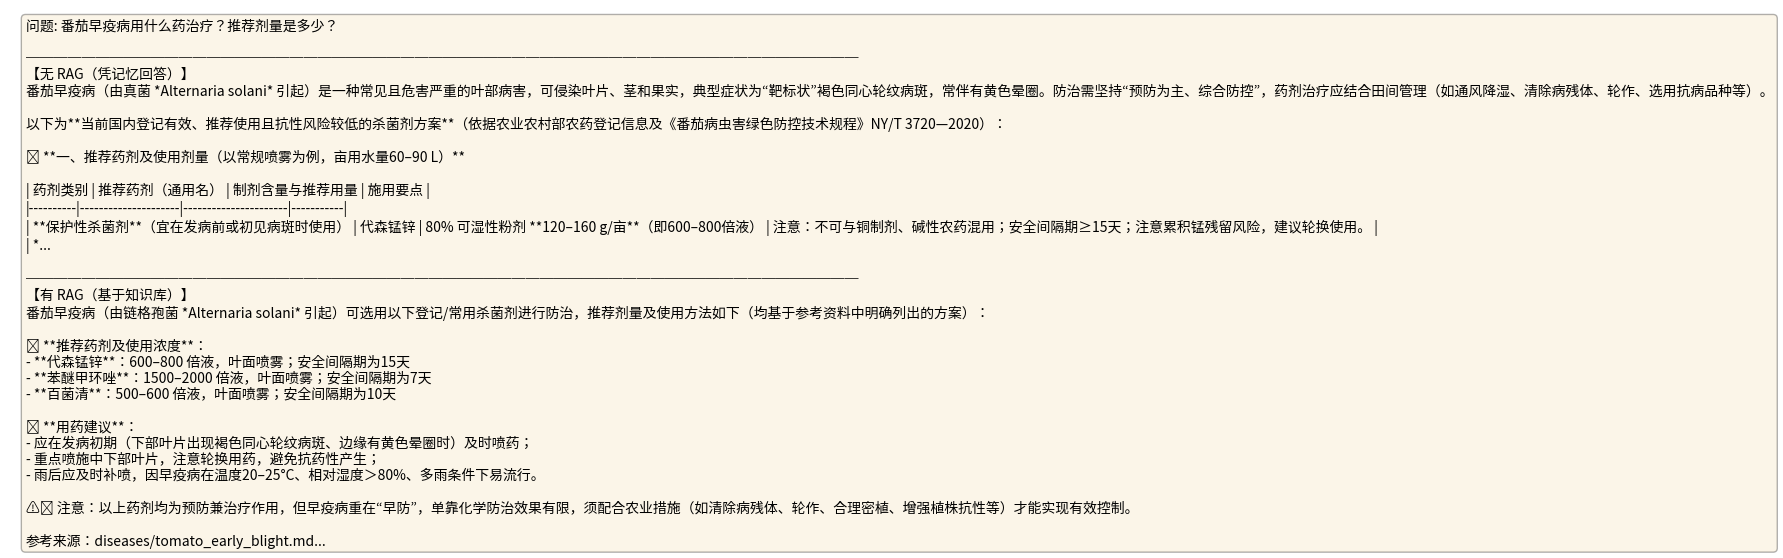

In [15]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
def compare_rag(question):
    """对比有/无 RAG 的回答"""
    import matplotlib.pyplot as plt

    # 无 RAG：直接问 LLM
    messages_no_rag = [
        {"role": "system", "content": "你是农业专家。"},
        {"role": "user", "content": question}
    ]
    answer_no_rag = client.chat.completions.create(
        model=MODEL, messages=messages_no_rag, temperature=0.5, max_tokens=512
    ).choices[0].message.content

    # 有 RAG
    answer_with_rag = retrieve_and_answer(question)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis("off")

    text = f"问题: {question}\n\n"
    text += f"{'─'*60}\n"
    text += f"【无 RAG（凭记忆回答）】\n{answer_no_rag[:500]}...\n\n"
    text += f"{'─'*60}\n"
    text += f"【有 RAG（基于知识库）】\n{answer_with_rag[:500]}..."

    ax.text(0.02, 0.98, text, transform=ax.transAxes, fontsize=10,
            verticalalignment="top", fontproperties=font_prop,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))

    plt.tight_layout()
    plt.savefig("task_b_rag_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

compare_rag("番茄早疫病用什么药治疗？推荐剂量是多少？")